In [63]:
# Imports
from scipy.io import arff
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

In [2]:
# Load the .arff file
path = '../data/raw/phpn1jVwe.arff' # Update this to the path of your .arff file
data, meta = arff.loadarff(path)

In [3]:
# Convert to DataFrame
df = pd.DataFrame(data)

In [4]:
df['class'] = df['class'].str.decode('utf-8')

In [5]:
# Save to CSV file
csv_file_name = 'Mammography.csv'
df.to_csv(csv_file_name, index=False)
print(f"Data saved to {csv_file_name}")

Data saved to Mammography.csv


In [6]:
df.head()

,attr1,attr2,attr3,attr4,attr5,attr6,class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,-1
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,-1
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,-1
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,-1
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,-1


In [20]:
# replace the string '-1' with integer 0
df['class'] = df['class'].replace('-1', '0')
df.head()

,attr1,attr2,attr3,attr4,attr5,attr6,class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,0
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,0
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,0
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,0
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,0


In [37]:
# Check the data types for each column
print(df.dtypes)

attr1    float64
attr2    float64
attr3    float64
attr4    float64
attr5    float64
attr6    float64
class     object
dtype: object


#### All features are numerical aside from target 'class'

## PART A: Feature Distribution

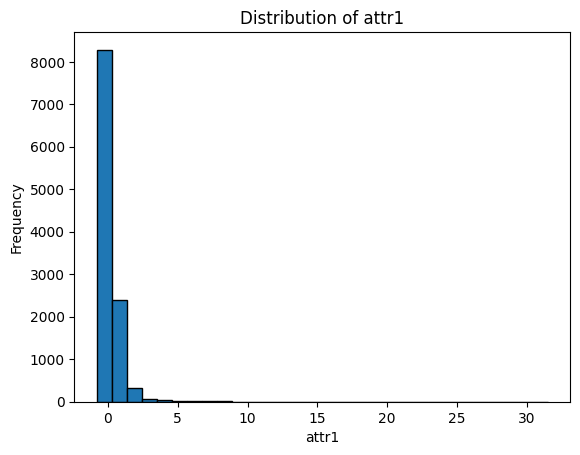

In [ ]:
# Visualize the univariate distribution of attr1
plt.hist(df['attr1'], bins=30, edgecolor='k')
plt.title('Distribution of attr1')
plt.xlabel('attr1')
plt.ylabel('Frequency')
plt.show()

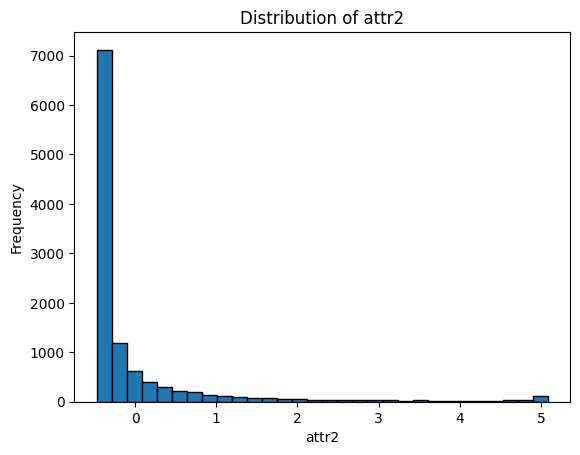

In [10]:
# Visualize univariate distrubution of attr2
plt.hist(df['attr2'], bins=30, edgecolor='k')
plt.title('Distribution of attr2')
plt.xlabel('attr2')
plt.ylabel('Frequency')
plt.show()

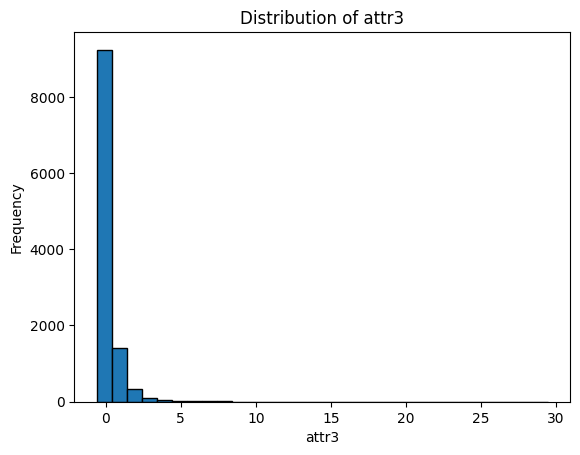

In [11]:
# Visualize the univariate distribution of attr3
plt.hist(df['attr3'], bins=30, edgecolor='k')
plt.title('Distribution of attr3')
plt.xlabel('attr3')
plt.ylabel('Frequency')
plt.show()

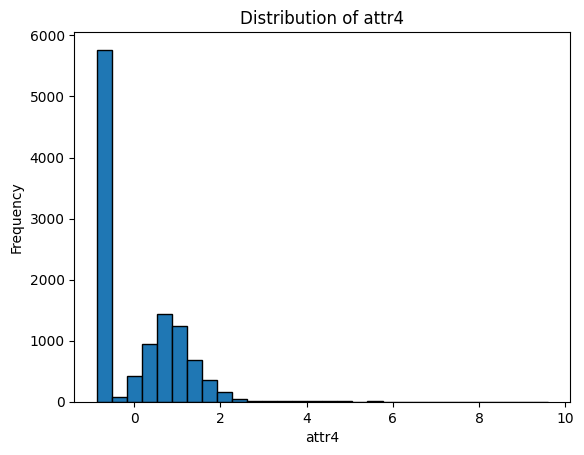

In [12]:
# Visualize the univariate distribution of attr4
plt.hist(df['attr4'], bins=30, edgecolor='k')
plt.title('Distribution of attr4')
plt.xlabel('attr4')
plt.ylabel('Frequency')
plt.show()

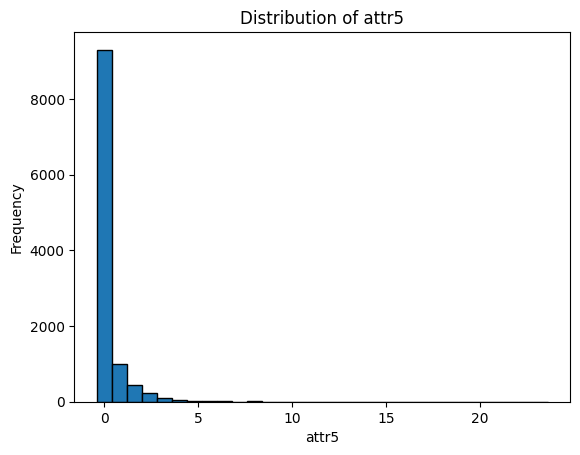

In [13]:
# Visualize univariate distribution of attr5
plt.hist(df['attr5'], bins=30, edgecolor='k')
plt.title('Distribution of attr5') 
plt.xlabel('attr5')
plt.ylabel('Frequency')
plt.show()

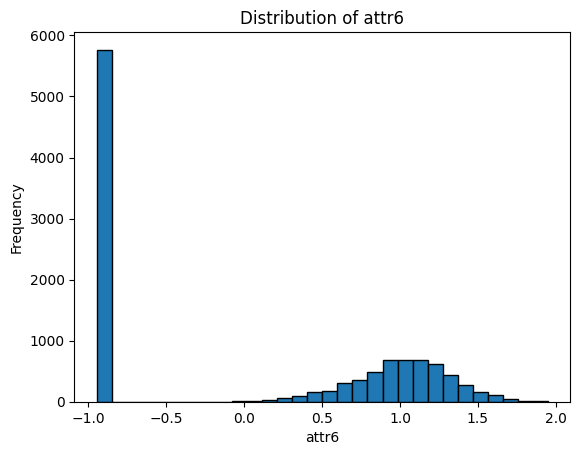

In [14]:
# Visualize univariate distribution of attr6
plt.hist(df['attr6'], bins=30, edgecolor='k')
plt.title('Distribution of attr6')
plt.xlabel('attr6')
plt.ylabel('Frequency')
plt.show()

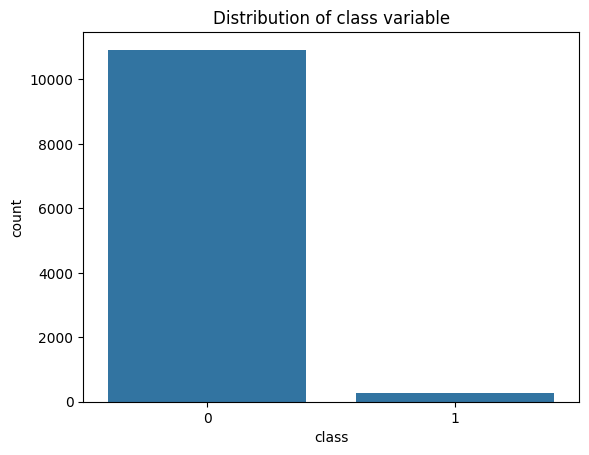

In [27]:
# Visualize the distribution of target variable 'class'
sns.countplot(x='class', data=df)
plt.title('Distribution of class variable')
plt.show()

In [28]:
# Count the occurences of each class in the 'class' column
print(df['class'].value_counts())

class
0    10923
1      260
Name: count, dtype: int64


## PART B: Pre-Processing

In [29]:
# Define features and target variable
X = df[['attr1','attr2','attr3','attr4','attr5','attr6']]
Y = df['class']

In [ ]:
# Add a random seed for reproducibility
np.random.seed(503)

# Split the dataset into training and testing sets (80% train, 20% test)
# Use stratify to maintain class distribution
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(8946, 6) (2237, 6) (8946,) (2237,)


In [43]:
# Use ColumnTransformer and StandardScaler to standardize the features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['attr1','attr2','attr3','attr4','attr5','attr6'])
    ])

In [44]:
# Add random seed for reproducibility
np.random.seed(511)

# Define a stratified 5-fold cross-validation strategy
cv = StratifiedKFold(n_splits=5)

# Create a pipeline with preprocessor and Random Forest classifer
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=511))
])

In [46]:
# Evaluate the Random Forest model using cross-validation
scores = cross_val_score(pipeline, X, Y, cv=cv, scoring='accuracy')
print(f'Cross-validation accuracy scores: {scores}')
print(f'Mean cross-validation accuracy: {scores.mean():.4f}')

Cross-validation accuracy scores: [0.98614215 0.98658918 0.98748324 0.98926655 0.98613596]
Mean cross-validation accuracy: 0.9871


In [ ]:
# Evaluate the Random Forest model using cross-validation and balanced accuracy score
scores_balanced = cross_val_score(pipeline, X, Y, cv=cv, scoring='balanced_accuracy')
print(f'Cross-validation balanced accuracy scores: {scores_balanced}')
print(f'Mean cross-validation balanced accuracy: {scores_balanced.mean():.4f}')

Cross-validation balanced accuracy scores: [0.74885584 0.74908467 0.77770199 0.78800366 0.77701465]
Mean cross-validation balanced accuracy: 0.7681


## PART C: Hyperparameter Tuning

In [50]:
# Define the parameter grid for hyperparameter tuning
param_grid = [
    {
        'classifier': [RandomForestClassifier(random_state=511)],
        'classifier__n_estimators': [300, 500, 1000]
    }
]

In [51]:
# Use GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv
)

In [69]:
# Random seed for reproducibility
np.random.seed(525)

# Fit the grid search to the data
grid_search.fit(X_train, Y_train)

,estimator,Pipeline(step..._state=511))])
,param_grid,"[{'classifier': [RandomForestC...dom_state=511)], 'classifier__n_estimators': [300, 500, ...]}]"
,scoring,'balanced_accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [71]:
# Find the best parameters and best score from the grid search
best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, best_score

({'classifier': RandomForestClassifier(random_state=511),
  'classifier__n_estimators': 500},
 np.float64(0.7528990680948238))

#### Best n_estimators: 500
#### Accuracy score: 75.29%

In [72]:
# Compare best parameters with other parameters from grid search
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values(by='mean_test_score', ascending=False)

results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier,param_classifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,3.401674,0.014522,0.073376,0.002598,RandomForestClassifier(random_state=511),500,{'classifier': RandomForestClassifier(random_s...,0.798295,0.736557,0.755032,0.789137,0.685474,0.752899,0.040477,1
0,2.113320,0.074616,0.046511,0.001640,RandomForestClassifier(random_state=511),300,{'classifier': RandomForestClassifier(random_s...,0.798580,0.736557,0.754745,0.779137,0.685474,0.750898,0.038915,2
2,7.004817,0.250252,0.147330,0.008885,RandomForestClassifier(random_state=511),1000,{'classifier': RandomForestClassifier(random_s...,0.781913,0.736557,0.755032,0.789137,0.685474,0.749623,0.037200,3


#### Mean Test Scores for n_estimators:
##### 500: 75.29%
##### 300: 75.09%
##### 1000: 74.96%

There is very minimal difference between accuracy for the different n_estimators.

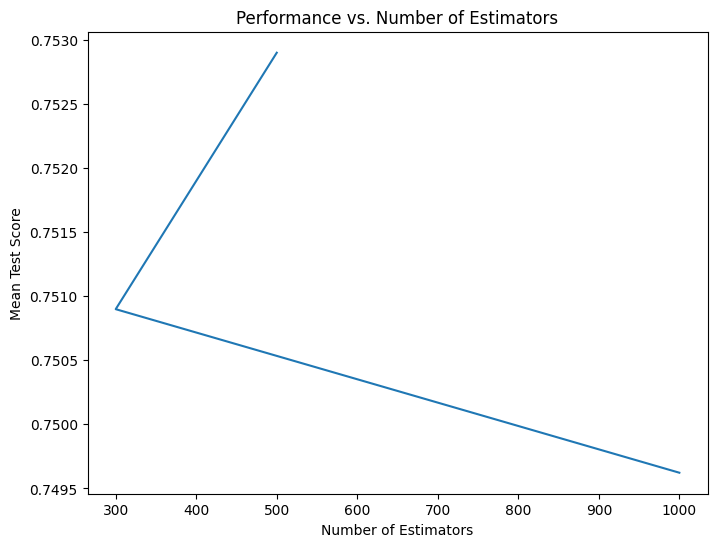

In [ ]:
# Visualize the performace as a function of n_estimators
plt.figure(figsize=(8, 6))
plt.plot(results_df['param_classifier__n_estimators'], results_df['mean_test_score'])
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Test Score')
plt.title('Performance vs. Number of Estimators')
plt.show()

# NOTE: Not sure why the line is going back on itself...

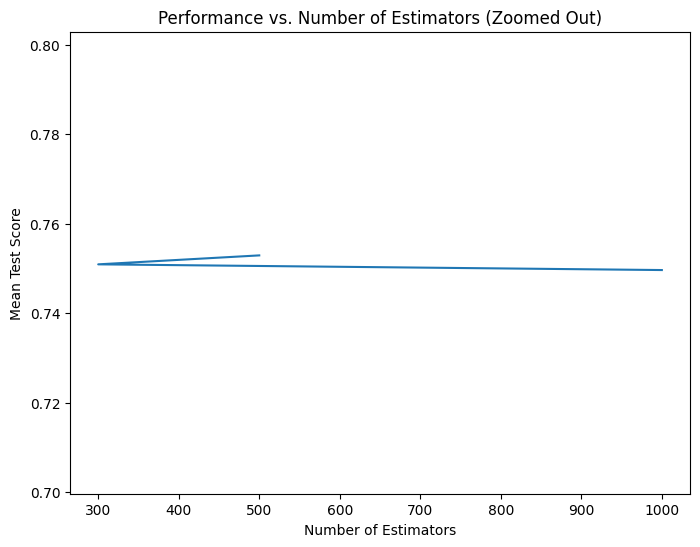

In [78]:
# Show the same plot but zoomed out on the y-axis
plt.figure(figsize=(8, 6))
plt.plot(results_df['param_classifier__n_estimators'], results_df['mean_test_score'])
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Test Score')
plt.title('Performance vs. Number of Estimators (Zoomed Out)')
plt.ylim(results_df['mean_test_score'].min() - 0.05, results_df['mean_test_score'].max() + 0.05)
plt.show()

## PART D: Switch Cross-Validation Strategy

In [80]:
# Random seed for reproducibility
np.random.seed(538)

# Switch cv strategy from stratified k-fold to k-fold with shuffling
cv = KFold(n_splits=5, shuffle=True, random_state=538)


In [81]:
# Do another GridSearchCV with the new cv strategy
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv
)

In [82]:
# Fit the new grid search to the data
grid_search.fit(X_train, Y_train)

,estimator,Pipeline(step..._state=511))])
,param_grid,"[{'classifier': [RandomForestC...dom_state=511)], 'classifier__n_estimators': [300, 500, ...]}]"
,scoring,'balanced_accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [83]:
# Find the best parameters and best score from the new grid search
best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, best_score

({'classifier': RandomForestClassifier(random_state=511),
  'classifier__n_estimators': 500},
 np.float64(0.7640731334706576))

#### Best n_estimators: 500
#### Accuracy score: 76.41%
This k-fold gave the same best estimator with little difference between the accuracy scores.

In [84]:
# Compare best parameters with other parameters from grid search
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values(by='mean_test_score', ascending=False)

results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier,param_classifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,3.462311,0.033957,0.072752,0.003692,RandomForestClassifier(random_state=511),500,{'classifier': RandomForestClassifier(random_s...,0.831908,0.717796,0.718750,0.768007,0.783905,0.764073,0.042909,1
2,6.855287,0.079480,0.142339,0.007125,RandomForestClassifier(random_state=511),1000,{'classifier': RandomForestClassifier(random_s...,0.831908,0.717796,0.718750,0.768007,0.783905,0.764073,0.042909,1
0,2.076498,0.045509,0.063915,0.037590,RandomForestClassifier(random_state=511),300,{'classifier': RandomForestClassifier(random_s...,0.831623,0.717796,0.718465,0.768007,0.783905,0.763959,0.042880,3


#### Mean Test Scores for n_estimators:
##### 500: 76.41%
##### 1000: 76.41%
##### 300: 76.4%

There is still very minimal difference between accuracy for the different n_estimators. 1000 and 300 switched rankings, but with how close their accuracy scores are, this is probably not indicative of anything other than randomness.

In [ ]:
# Try again with a different random seed for the shuffling

In [ ]:
# Try again with different random state for training and testing split